## Notebook 2 — Patient-Level Split Summary

**Input:** `piyarathne_standardized.csv` (3,000 images, 714 patients) — output of Notebook 1 (preprocessing & QC).

### Problem
A naive image-level split would leak patients across train/val/test, since many patients contribute multiple images. Splitting had to be done by `patient_id`, not by image.

### Step 1 — Multi-label patients
Each image carries its own `Category` (OCA / OPMD / Benign / Healthy), but a patient is not guaranteed a single label: **193 of 714 patients (27%)** have images spanning more than one category — typically because different regions of the same mouth were photographed separately, or a patient has more than one co-occurring finding.

### Step 2 — Patient-level label assignment
Resolved via a **worst-case severity rule** (OCA > OPMD > Benign > Healthy): a patient is assigned the most severe category found among any of their images. This protects rare/critical classes (especially OCA) from being diluted by a majority of unaffected images from the same patient. This label (`patient_label`) is used **only** to drive stratification — it is not a substitute for the true image-level `Category`, which remains the training target.

Resulting patient-level distribution:

| Category | Patients | Images |
|---|---|---|
| OCA | 61 | 129 |
| Healthy | 91 | 729 |
| Benign | 242 | 748 |
| OPMD | 320 | 1394 |

### Step 3 — Split strategy
Given OCA's small size (61 patients), a single fixed train/val/test split would leave too few OCA patients (~9) in any held-out set to trust as a stable metric. Instead, used **patient-grouped, stratified 5-fold cross-validation** (`StratifiedKFold` on one-row-per-patient, `patient_id` merged back onto the image table):

- Each of the 5 folds holds ~143 patients, with proportional representation of all 4 categories (OCA: 12–13 per fold).
- **No patient appears in more than one fold** (verified via assertion — zero leakage).
- Image-level counts per fold vary more than patient counts (e.g. OCA images range 14–40 per fold), since images-per-patient isn't uniform. Noted for Notebook 3: **aggregate metrics via pooled out-of-fold (OOF) predictions**, not a plain average of per-fold scores, to avoid weighting small folds and large folds equally.
- `source_dataset` confirmed single-source (`piyarathne`) — no cross-source imbalance to worry about.
- No separate held-out test set was carved out; all 714 patients participate in the 5-fold CV. External/held-out testing, if needed, will be done on a separate external dataset rather than a static holdout here.

### Output
Saved to `/kaggle/working/piyarathne_split.csv` — the original 3,000-row image-level table plus two new columns: `fold` (0–4, for CV) and `patient_label` (stratification label, not a training target).

### For Notebook 3
- Train on `Category` (image-level ground truth).
- Loop over `fold` 0–4 for cross-validation; use `fold != k` as train, `fold == k` as val for each iteration `k`.
- Report OCA metrics via pooled out-of-fold predictions across all 5 folds, plus per-fold mean ± std as a secondary stability check.

In [1]:
# Cell 1 — Imports and load standardized dataset from Notebook 1
import pandas as pd
import numpy as np
from pathlib import Path

IMAGE_DIR = Path('/kaggle/input/notebooks/syedjaffarrazakazmi/01-piyarathne-preprocessing-and-qc-ipynb/piyarathne/images')
input_csv = Path('/kaggle/input/notebooks/syedjaffarrazakazmi/01-piyarathne-preprocessing-and-qc-ipynb/piyarathne_standardized.csv')

df = pd.read_csv(input_csv)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (3000, 12)
Columns: ['source_dataset', 'image_id', 'file_name', 'image_stem', 'width', 'height', 'coco_categories', 'Image Name', 'Category', 'Clinical Diagnosis', 'Lesion Annotation Count', 'patient_id']


,source_dataset,image_id,file_name,image_stem,width,height,coco_categories,Image Name,Category,Clinical Diagnosis,Lesion Annotation Count,patient_id
0,piyarathne,1,R-01-01.jpg,R-01-01,4608,3456,"['Lesion', 'Oral Cavity']",R-01-01,OPMD,Leukoplakia,1,R-01
1,piyarathne,2,R-01-02.jpg,R-01-02,4608,3456,"['Oral Cavity', 'Lesion']",R-01-02,OPMD,Leukoplakia,1,R-01
2,piyarathne,3,R-01-03.jpg,R-01-03,3456,4608,"['Oral Cavity', 'Lesion']",R-01-03,Benign,Coated Tongue,1,R-01
3,piyarathne,4,R-02-01.jpg,R-02-01,4608,3456,"['Lesion', 'Oral Cavity']",R-02-01,Benign,VBD,1,R-02
4,piyarathne,5,R-02-02.jpg,R-02-02,4608,3456,"['Lesion', 'Oral Cavity']",R-02-02,Benign,VBD,1,R-02


In [2]:
# Cell 2 — Patient-level label consistency check
patient_category_counts = df.groupby('patient_id')['Category'].nunique()

n_multi_label_patients = (patient_category_counts > 1).sum()
n_total_patients = df['patient_id'].nunique()

print(f"Total patients: {n_total_patients}")
print(f"Patients with >1 distinct Category across their images: {n_multi_label_patients} "
      f"({n_multi_label_patients / n_total_patients:.1%})")

# Peek at a few mixed-label patients
mixed_patients = patient_category_counts[patient_category_counts > 1].index
df[df['patient_id'].isin(mixed_patients)].sort_values('patient_id')[
    ['patient_id', 'image_stem', 'Category', 'Clinical Diagnosis']
].head(15)

Total patients: 714
Patients with >1 distinct Category across their images: 193 (27.0%)


,patient_id,image_stem,Category,Clinical Diagnosis
1429,C-44,C-44-1-1,Healthy,Normal Mucosa
1433,C-44,C-44-6-3,Healthy,Normal Mucosa
1432,C-44,C-44-6-2,Healthy,Normal Mucosa
1430,C-44,C-44-4-4,Healthy,Normal Mucosa
1431,C-44,C-44-5-5,Healthy,Normal Mucosa
1434,C-44,C-44-7-6,Benign,Geographic Tongue
1435,C-44,C-44-8-7,Healthy,Normal Mucosa
738,K-003,K-003-01,Benign,Coated Tongue
742,K-003,K-003-05,Healthy,Normal Mucosa
739,K-003,K-003-02,Benign,Ulcer


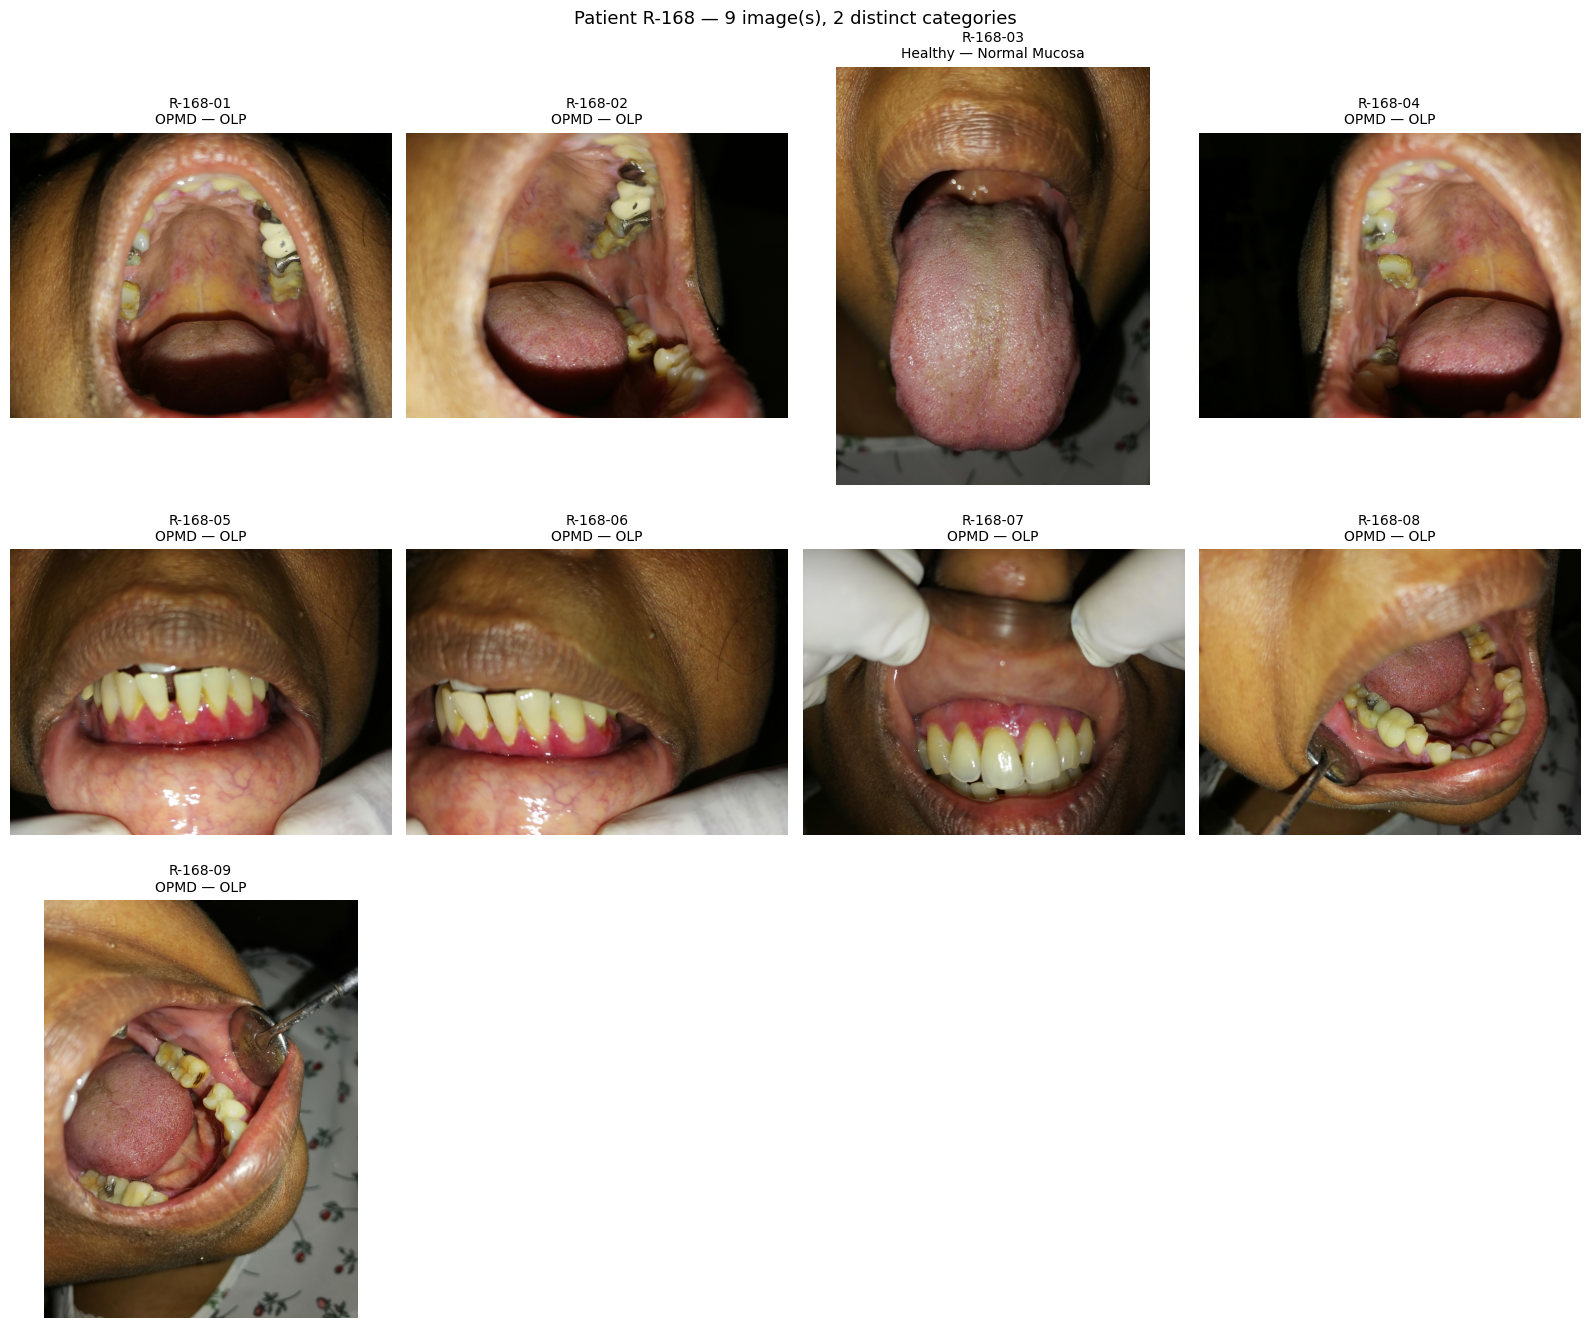

In [3]:
# Display all images of a random multi-label patient with their Category labels
import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

random_patient = random.choice(mixed_patients)
patient_rows = df[df['patient_id'] == random_patient].sort_values('image_stem')

n = len(patient_rows)
n_cols = min(4, n)
n_rows = -(-n // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4.5 * n_rows))
axes = axes.flatten() if n > 1 else [axes]

for ax, (_, row) in zip(axes, patient_rows.iterrows()):
    img_path = IMAGE_DIR / row['file_name']
    with Image.open(img_path) as im:
        ax.imshow(im)
    ax.set_title(f"{row['image_stem']}\n{row['Category']} — {row['Clinical Diagnosis']}", fontsize=10)
    ax.axis('off')

# Hide any unused subplot axes
for ax in axes[n:]:
    ax.axis('off')

fig.suptitle(f"Patient {random_patient} — {n} image(s), {patient_rows['Category'].nunique()} distinct categories", fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
# Cell 3 — Assign patient-level label via worst-case severity rule
severity_order = {'OCA': 0, 'OPMD': 1, 'Benign': 2, 'Healthy': 3}  # lower = more severe

assert df['Category'].isna().sum() == 0, "Unexpected NaNs in Category"
unknown_cats = set(df['Category'].unique()) - set(severity_order.keys())
assert not unknown_cats, f"Unrecognized Category values: {unknown_cats}"

df['_severity_rank'] = df['Category'].map(severity_order)

patient_label = (
    df.sort_values('_severity_rank')
      .groupby('patient_id')
      .first()['Category']
      .rename('patient_label')
)

df = df.drop(columns='_severity_rank')

print("Patient-level label distribution (worst-case rule):")
print(patient_label.value_counts())
print(f"\nTotal patients: {patient_label.shape[0]}")

print("\nImage-level Category distribution (for comparison):")
print(df['Category'].value_counts())

Patient-level label distribution (worst-case rule):
patient_label
OPMD       320
Benign     242
Healthy     91
OCA         61
Name: count, dtype: int64

Total patients: 714

Image-level Category distribution (for comparison):
Category
OPMD       1394
Benign      748
Healthy     729
OCA         129
Name: count, dtype: int64


In [5]:
# Cell — Patient-level stratified 5-fold split (primary CV strategy)
from sklearn.model_selection import StratifiedKFold

N_FOLDS = 5
RANDOM_STATE = 42

# One row per patient, with their worst-case-rule label (built in Cell 3)
patient_df = patient_label.reset_index()  # columns: patient_id, patient_label
patient_df = patient_df.sort_values('patient_id').reset_index(drop=True)  # deterministic order pre-shuffle

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

patient_df['fold'] = -1
for fold_idx, (_, val_idx) in enumerate(skf.split(patient_df['patient_id'], patient_df['patient_label'])):
    patient_df.loc[val_idx, 'fold'] = fold_idx

assert (patient_df['fold'] == -1).sum() == 0, "Some patients weren't assigned a fold"

# Merge fold assignment back onto the image-level dataframe
df = df.merge(patient_df[['patient_id', 'fold']], on='patient_id', how='left')
assert df['fold'].isna().sum() == 0, "Some images lost their fold assignment in the merge"
df['fold'] = df['fold'].astype(int)

# --- Sanity checks ---
print("Patients per fold:")
print(patient_df['fold'].value_counts().sort_index())

print("\nPatient-level label distribution per fold:")
print(pd.crosstab(patient_df['fold'], patient_df['patient_label']))

print("\nImage-level Category distribution per fold:")
print(pd.crosstab(df['fold'], df['Category']))

# No patient should ever appear in more than one fold
leak_check = df.groupby('patient_id')['fold'].nunique()
assert (leak_check == 1).all(), "Leakage detected: some patients span multiple folds!"
print("\nNo patient-level leakage across folds.")

# Guarantee every fold has a usable number of OCA patients for evaluation
oca_per_fold = patient_df[patient_df['patient_label'] == 'OCA']['fold'].value_counts().sort_index()
print("\nOCA patients per fold:")
print(oca_per_fold)
assert oca_per_fold.min() >= 5, f"A fold has too few OCA patients to evaluate on: {oca_per_fold.min()}"
print("Every fold has at least 5 OCA patients.")

Patients per fold:
fold
0    143
1    143
2    143
3    143
4    142
Name: count, dtype: int64

Patient-level label distribution per fold:
patient_label  Benign  Healthy  OCA  OPMD
fold                                     
0                  48       19   12    64
1                  49       18   12    64
2                  49       18   12    64
3                  48       18   13    64
4                  48       18   12    64

Image-level Category distribution per fold:
Category  Benign  Healthy  OCA  OPMD
fold                                
0            164      119   14   271
1            127      153   40   281
2            134      134   21   305
3            167      168   31   269
4            156      155   23   268

No patient-level leakage across folds.

OCA patients per fold:
fold
0    12
1    12
2    12
3    13
4    12
Name: count, dtype: int64
Every fold has at least 5 OCA patients.


In [6]:
# Cell — Save patient-level split output for Notebook 3
output_path = Path('/kaggle/working/piyarathne_split.csv')

# Keep patient_label alongside fold for transparency/debugging downstream,
# even though the actual training target remains the image-level `Category`
df_out = df.merge(
    patient_df[['patient_id', 'patient_label']],
    on='patient_id',
    how='left',
    suffixes=('', '_dup')
)

assert df_out['patient_label'].isna().sum() == 0, "Some images missing patient_label after merge"
assert len(df_out) == len(df), "Row count changed during merge — check for duplicate patient_ids"

df_out.to_csv(output_path, index=False)

print(f"Saved {len(df_out)} rows, {df_out['patient_id'].nunique()} patients to {output_path}")
print(f"Columns: {df_out.columns.tolist()}")
df_out.head()

Saved 3000 rows, 714 patients to /kaggle/working/piyarathne_split.csv
Columns: ['source_dataset', 'image_id', 'file_name', 'image_stem', 'width', 'height', 'coco_categories', 'Image Name', 'Category', 'Clinical Diagnosis', 'Lesion Annotation Count', 'patient_id', 'fold', 'patient_label']


,source_dataset,image_id,file_name,image_stem,width,height,coco_categories,Image Name,Category,Clinical Diagnosis,Lesion Annotation Count,patient_id,fold,patient_label
0,piyarathne,1,R-01-01.jpg,R-01-01,4608,3456,"['Lesion', 'Oral Cavity']",R-01-01,OPMD,Leukoplakia,1,R-01,3,OPMD
1,piyarathne,2,R-01-02.jpg,R-01-02,4608,3456,"['Oral Cavity', 'Lesion']",R-01-02,OPMD,Leukoplakia,1,R-01,3,OPMD
2,piyarathne,3,R-01-03.jpg,R-01-03,3456,4608,"['Oral Cavity', 'Lesion']",R-01-03,Benign,Coated Tongue,1,R-01,3,OPMD
3,piyarathne,4,R-02-01.jpg,R-02-01,4608,3456,"['Lesion', 'Oral Cavity']",R-02-01,Benign,VBD,1,R-02,2,Benign
4,piyarathne,5,R-02-02.jpg,R-02-02,4608,3456,"['Lesion', 'Oral Cavity']",R-02-02,Benign,VBD,1,R-02,2,Benign
